# Titanic Project — Part 2: Clean Preprocessing & Modeling

**Goal:** Turn the exploratory/preprocessing work from Part 1 into a clean, reproducible machine-learning workflow.

This notebook intentionally contains **only the project workflow**. Practice exercises, repeated experiments, duplicate train/test splits, and intermediate learning cells have been removed.

### Workflow
1. Load and inspect the dataset
2. Create project features
3. Separate target and features
4. Train/test split
5. Build preprocessing pipelines
6. Build the Logistic Regression pipeline
7. Train and evaluate
8. Inspect processed feature names
9. Save the trained pipeline


## 1. Imports & Dataset Loading

In [1]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("train.csv")

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Quick Dataset Check

In [2]:
print("Shape:", df.shape)
print("\nData types and non-null counts:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate PassengerId values:", df["PassengerId"].duplicated().sum())

print("\nTarget distribution:")
print(df["Survived"].value_counts())

print("\nTarget proportion:")
print(df["Survived"].value_counts(normalize=True).mul(100).round(2))


Shape: (891, 12)

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare  

## 3. Feature Engineering & Initial Cleanup

Decisions carried forward from Part 1:

- `PassengerId` is an identifier and is removed.
- `Ticket` is removed.
- `Name` is used to extract `Title`, then removed.
- `Cabin` is converted into `HasCabin` because most cabin values are missing.
- `FamilySize = SibSp + Parch + 1`
- `IsAlone = 1` when `FamilySize == 1`, otherwise `0`.
- `Mlle` and `Ms` are grouped with `Miss`; `Mme` is grouped with `Mrs`.
- Rare titles (frequency < 10) are grouped into `Rare`.

**Important:** missing-value imputation used for model training is handled later inside the preprocessing pipeline so that the imputer learns only from the training data.


In [3]:
# Drop identifier / high-cardinality columns that were not selected for modeling
df = df.drop(columns=["PassengerId", "Ticket"])

# Extract title from Name
df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.")

# Group equivalent titles
df["Title"] = df["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})

# Group rare titles
title_counts = df["Title"].value_counts()
rare_titles = title_counts[title_counts < 10].index
df["Title"] = df["Title"].replace(rare_titles, "Rare")

# Convert Cabin information into a binary feature
df["HasCabin"] = df["Cabin"].notna().astype(int)

# Drop raw columns after extracting useful information
df = df.drop(columns=["Name", "Cabin"])

# Feature engineering
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,HasCabin,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,Mr,0,2,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,1,2,0
2,1,3,female,26.0,0,0,7.9250,S,Miss,0,1,1
3,1,1,female,35.0,1,0,53.1000,S,Mrs,1,2,0
4,0,3,male,35.0,0,0,8.0500,S,Mr,0,1,1


In [4]:
print("Final project columns:")
print(df.columns.tolist())

print("\nRemaining missing values:")
print(df.isnull().sum())


Final project columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'HasCabin', 'FamilySize', 'IsAlone']

Remaining missing values:
Survived        0
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare            0
Embarked        2
Title           0
HasCabin        0
FamilySize      0
IsAlone         0
dtype: int64


## 4. Define Target and Features

In [5]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (891, 11)
y shape: (891,)


## 5. Train/Test Split

The test set is kept unseen during preprocessing and model training.

`stratify=y` preserves the target-class distribution in both splits.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (712, 11)
X_test : (179, 11)
y_train: (712,)
y_test : (179,)


## 6. Define Feature Groups

In [7]:
numerical_columns = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]

categorical_columns = [
    "Sex",
    "Embarked",
    "Title"
]

ordinal_columns = [
    "Pclass"
]

binary_columns = [
    "IsAlone",
    "HasCabin"
]


## 7. Build Preprocessing Pipelines

### Numerical
Median imputation → StandardScaler

### Categorical
Most-frequent imputation → One-Hot Encoding

### Ordinal
Ordinal encoding for `Pclass`

### Binary
Pass through unchanged because `IsAlone` and `HasCabin` are already 0/1 features.


In [8]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder())
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns),
    ("ord", ordinal_pipeline, ordinal_columns),
    ("binary", "passthrough", binary_columns)
])


## 8. Complete Machine Learning Pipeline

The preprocessing and model are placed into one pipeline so the exact same learned transformations are applied to future data.


In [9]:
import time 
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

model_pipeline.fit(X_train, y_train)




,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Pclass','Sex','Age',...,'HasCabin','FamilySize','IsAlone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remain

## 9. Evaluation

In [10]:
y_pred = model_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.8324022346368715

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       110
           1       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

Confusion Matrix:
[[97 13]
 [17 52]]


## 10. Processed Feature Names

In [11]:
feature_names = model_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

print("Total processed features:", len(feature_names))

for i, feature in enumerate(feature_names, start=1):
    print(f"{i:2d}. {feature}")


Total processed features: 18
 1. num__Age
 2. num__SibSp
 3. num__Parch
 4. num__Fare
 5. num__FamilySize
 6. cat__Sex_female
 7. cat__Sex_male
 8. cat__Embarked_C
 9. cat__Embarked_Q
10. cat__Embarked_S
11. cat__Title_Master
12. cat__Title_Miss
13. cat__Title_Mr
14. cat__Title_Mrs
15. cat__Title_Rare
16. ord__Pclass
17. binary__IsAlone
18. binary__HasCabin


## 11. Save the Complete Pipeline

Saving the complete pipeline means the preprocessing steps and Logistic Regression model are stored together.


In [12]:
joblib.dump(
    model_pipeline,
    "titanic_model_pipeline.pkl"
)

print("Pipeline saved as titanic_model_pipeline.pkl")


Pipeline saved as titanic_model_pipeline.pkl


## 12. Project Summary

### Final modeling features

- **Numerical:** Age, SibSp, Parch, Fare, FamilySize
- **Categorical:** Sex, Embarked, Title
- **Ordinal:** Pclass
- **Binary:** IsAlone, HasCabin

### Preprocessing

- Numerical → median imputation + standardization
- Categorical → most-frequent imputation + one-hot encoding
- Ordinal → most-frequent imputation + ordinal encoding
- Binary → passthrough

### Modeling workflow added below

1. Baseline models
2. Stratified K-Fold cross-validation
3. Hyperparameter tuning with GridSearchCV
4. Tuned-model evaluation
5. Feature importance
6. Training/prediction timing
7. Final model comparison

### Key principle

The preprocessing is fitted inside each ML pipeline, so cross-validation and hyperparameter tuning do not leak information from validation folds into preprocessing.

# Part 2 — Model Improvement, Cross-Validation & Hyperparameter Tuning

We will now compare five classification models:

- Logistic Regression
- Decision Tree
- Random Forest
- KNN
- Naive Bayes

Then we will tune four models:

- Logistic Regression
- Decision Tree
- Random Forest
- KNN

**Validation strategy:** Stratified 5-Fold Cross-Validation.

**Scoring metric for GridSearchCV:** Accuracy, matching the current project objective.

The test set is kept untouched until final evaluation.

## 13. Modeling Imports & Common Evaluation Setup


In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 14. Reusable Evaluation Function


In [14]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print(f"Accuracy : {results['Accuracy']:.4f}")
    print(f"Precision: {results['Precision']:.4f}")
    print(f"Recall   : {results['Recall']:.4f}")
    print(f"F1       : {results['F1']:.4f}")
    print(f"ROC-AUC  : {results['ROC-AUC']:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return results

## 15. Baseline Models

These are **default/untuned models**. We evaluate them first so that we have a baseline before tuning.

In [15]:
baseline_models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]),

    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Naive Bayes": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GaussianNB())
    ])
}

In [16]:
baseline_results = []

for model_name, model in baseline_models.items():
    model.fit(X_train, y_train)
    result = evaluate_model(model, X_test, y_test, model_name)
    baseline_results.append(result)

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df.sort_values("F1", ascending=False)


Logistic Regression
-------------------
Accuracy : 0.8324
Precision: 0.8000
Recall   : 0.7536
F1       : 0.7761
ROC-AUC  : 0.8721

Confusion Matrix:
[[97 13]
 [17 52]]

Decision Tree
-------------
Accuracy : 0.7877
Precision: 0.7183
Recall   : 0.7391
F1       : 0.7286
ROC-AUC  : 0.7749

Confusion Matrix:
[[90 20]
 [18 51]]

Random Forest
-------------
Accuracy : 0.7877
Precision: 0.7246
Recall   : 0.7246
F1       : 0.7246
ROC-AUC  : 0.8252

Confusion Matrix:
[[91 19]
 [19 50]]

KNN
---
Accuracy : 0.8045
Precision: 0.7656
Recall   : 0.7101
F1       : 0.7368
ROC-AUC  : 0.8432

Confusion Matrix:
[[95 15]
 [20 49]]

Naive Bayes
-----------
Accuracy : 0.8156
Precision: 0.7500
Recall   : 0.7826
F1       : 0.7660
ROC-AUC  : 0.8515

Confusion Matrix:
[[92 18]
 [15 54]]


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.832402,0.800000,0.753623,0.776119,0.872069
4,Naive Bayes,0.815642,0.750000,0.782609,0.765957,0.851515
3,KNN,0.804469,0.765625,0.710145,0.736842,0.843215
1,Decision Tree,0.787709,0.718310,0.739130,0.728571,0.774901
2,Random Forest,0.787709,0.724638,0.724638,0.724638,0.825165


## 16. Stratified K-Fold Cross-Validation

We use the same 5-fold StratifiedKFold strategy for every baseline model so the comparison is fair.

The preprocessing remains inside each Pipeline, so each fold learns imputation/scaling/encoding only from its training portion.

In [17]:
cv_results = []

for model_name, model in baseline_models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.sort_values("CV Mean Accuracy", ascending=False)

,Model,CV Mean Accuracy,CV Std
0,Logistic Regression,0.825864,0.024383
2,Random Forest,0.824485,0.015448
4,Naive Bayes,0.807623,0.029787
3,KNN,0.804806,0.014583
1,Decision Tree,0.782281,0.019100


# 17. Hyperparameter Tuning

We tune only on `X_train`/`y_train`.

**Important:** `X_test` is not used to select hyperparameters.

## 17.1 Tuned Logistic Regression


In [18]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

param_grid_logistic = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear", "saga"]
}

grid_search_logistic = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_logistic,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

grid_search_logistic.fit(X_train, y_train)

best_logistic = grid_search_logistic.best_estimator_

print("Best Parameters:", grid_search_logistic.best_params_)
print("Best CV Score:", grid_search_logistic.best_score_)

logistic_tuned_results = evaluate_model(
    best_logistic,
    X_test,
    y_test,
    "Tuned Logistic Regression"
)

Best Parameters: {'model__C': 10, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV Score: 0.8272825765783512

Tuned Logistic Regression
-------------------------
Accuracy : 0.8380
Precision: 0.8030
Recall   : 0.7681
F1       : 0.7852
ROC-AUC  : 0.8762

Confusion Matrix:
[[97 13]
 [16 53]]


C:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## 17.2 Tuned Decision Tree


In [33]:
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

param_grid_tree = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_search_tree = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=param_grid_tree,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

grid_search_tree.fit(X_train, y_train)

best_tree = grid_search_tree.best_estimator_

print("Best Parameters:", grid_search_tree.best_params_)
print("Best CV Score:", grid_search_tree.best_score_)

tree_tuned_results = evaluate_model(
    best_tree,
    X_test,
    y_test,
    "Tuned Decision Tree"
)

Best Parameters: {'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best CV Score: 0.8216389244558258

Tuned Decision Tree
-------------------
Accuracy : 0.8324
Precision: 0.8197
Recall   : 0.7246
F1       : 0.7692
ROC-AUC  : 0.8530

Confusion Matrix:
[[99 11]
 [19 50]]


## 17.3 Tuned Random Forest


In [34]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

param_grid_rf = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5, 10]
}

grid_search_rf = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid_rf,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_

print("Best Parameters:", grid_search_rf.best_params_)
print("Best CV Score:", grid_search_rf.best_score_)

rf_tuned_results = evaluate_model(
    best_rf,
    X_test,
    y_test,
    "Tuned Random Forest"
)

Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV Score: 0.8329065300896286

Tuned Random Forest
-------------------
Accuracy : 0.8045
Precision: 0.7576
Recall   : 0.7246
F1       : 0.7407
ROC-AUC  : 0.8439

Confusion Matrix:
[[94 16]
 [19 50]]


## 17.4 Tuned KNN


In [35]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

grid_search_knn = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid_knn,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

grid_search_knn.fit(X_train, y_train)

best_knn = grid_search_knn.best_estimator_

print("Best Parameters:", grid_search_knn.best_params_)
print("Best CV Score:", grid_search_knn.best_score_)

knn_tuned_results = evaluate_model(
    best_knn,
    X_test,
    y_test,
    "Tuned KNN"
)

Best Parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 11, 'model__weights': 'uniform'}
Best CV Score: 0.8202304737516005

Tuned KNN
---------
Accuracy : 0.8268
Precision: 0.8065
Recall   : 0.7246
F1       : 0.7634
ROC-AUC  : 0.8644

Confusion Matrix:
[[98 12]
 [19 50]]


## 18. RandomizedSearchCV — Introduction

GridSearchCV checks every combination in the specified grid.

RandomizedSearchCV samples a fixed number of combinations instead. It is useful when the search space becomes very large.

Example only — not required for the final Titanic comparison:

In [36]:
from sklearn.model_selection import RandomizedSearchCV

random_search_example = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=param_grid_rf,
    n_iter=5,
    cv=skf,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

# Uncomment to run:
# random_search_example.fit(X_train, y_train)
# print(random_search_example.best_params_)
# print(random_search_example.best_score_)

## 19. Feature Importance — Tuned Decision Tree


In [37]:
tree_model = best_tree.named_steps["model"]

tree_feature_names = best_tree.named_steps[
    "preprocessor"
].get_feature_names_out()

tree_importance = tree_model.feature_importances_

tree_feature_importance_df = pd.DataFrame({
    "Feature": tree_feature_names,
    "Importance": tree_importance
}).sort_values(
    "Importance",
    ascending=False
)

tree_feature_importance_df.head(10)

,Feature,Importance
12,cat__Title_Mr,0.629751
15,ord__Pclass,0.155470
4,num__FamilySize,0.082455
14,cat__Title_Rare,0.061480
17,binary__HasCabin,0.050359
0,num__Age,0.012965
3,num__Fare,0.007520
1,num__SibSp,0.000000
2,num__Parch,0.000000
5,cat__Sex_female,0.000000


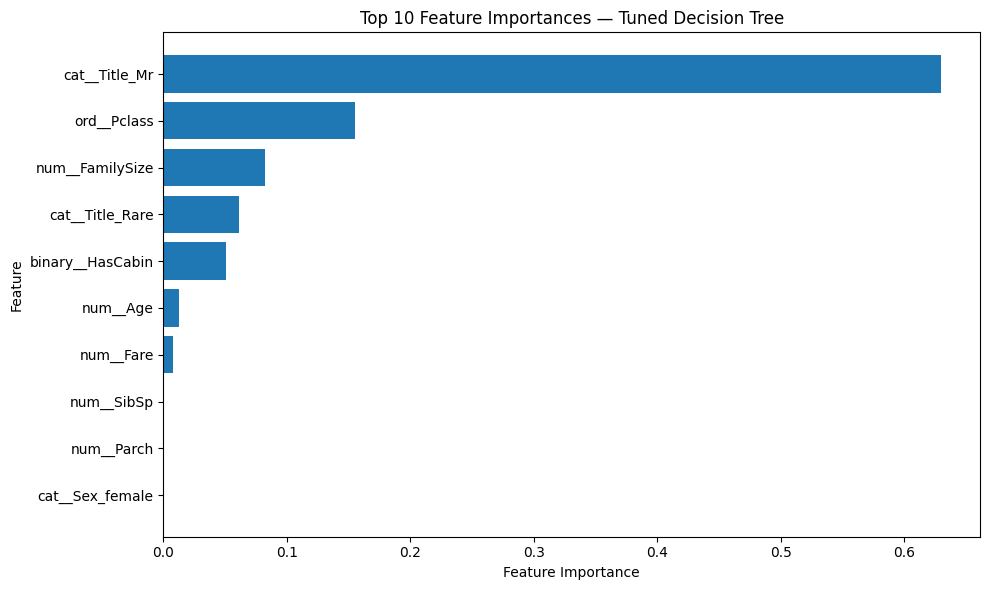

In [38]:
top_tree_features = tree_feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_tree_features["Feature"][::-1],
    top_tree_features["Importance"][::-1]
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances — Tuned Decision Tree")
plt.tight_layout()
plt.show()

## 20. Feature Importance — Tuned Random Forest


In [39]:
rf_model = best_rf.named_steps["model"]

rf_feature_names = best_rf.named_steps[
    "preprocessor"
].get_feature_names_out()

rf_importance = rf_model.feature_importances_

rf_feature_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importance
}).sort_values(
    "Importance",
    ascending=False
)

rf_feature_importance_df.head(10)

,Feature,Importance
3,num__Fare,0.187842
0,num__Age,0.161722
5,cat__Sex_female,0.118495
6,cat__Sex_male,0.100300
12,cat__Title_Mr,0.099477
15,ord__Pclass,0.075954
17,binary__HasCabin,0.052494
4,num__FamilySize,0.043410
11,cat__Title_Miss,0.029722
1,num__SibSp,0.026705


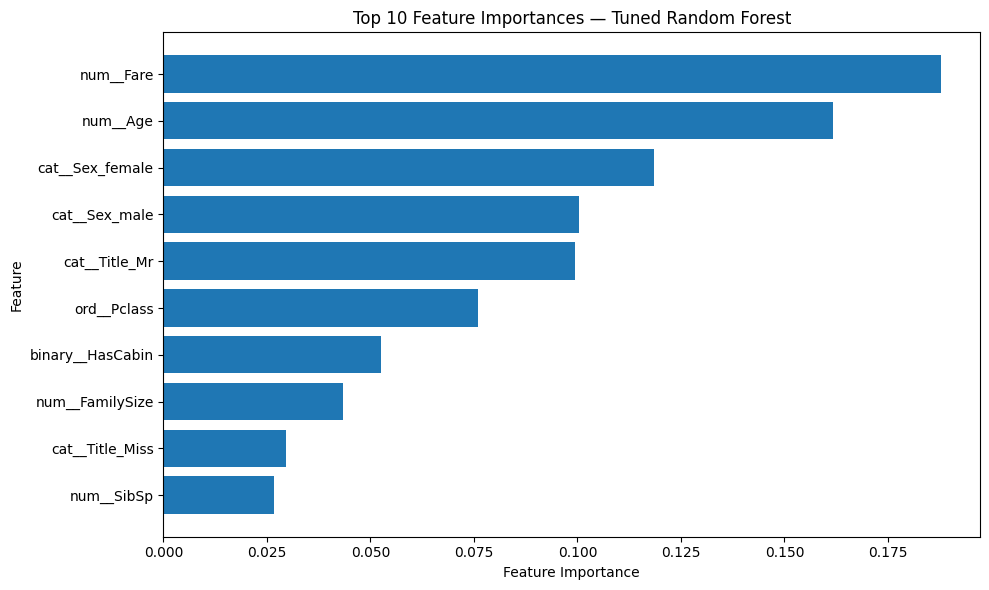

In [40]:
top_rf_features = rf_feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_rf_features["Feature"][::-1],
    top_rf_features["Importance"][::-1]
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances — Tuned Random Forest")
plt.tight_layout()
plt.show()

## 21. Training Time & Prediction Time

For this small Titanic dataset, timing differences are tiny. We measure the **final selected estimator** rather than the entire GridSearchCV process.

Use repeated runs to make very small timings more stable.

In [45]:
def measure_time(model, X_train, y_train, X_test, repeats=100):
    start = time.perf_counter()

    for _ in range(repeats):
        model.fit(X_train, y_train)

    training_time = (time.perf_counter() - start) / repeats

    start = time.perf_counter()

    for _ in range(repeats):
        model.predict(X_test)

    prediction_time = (time.perf_counter() - start) / repeats

    return training_time, prediction_time

In [49]:
import time
import pandas as pd

models_to_time = {
    "Tuned Logistic Regression": best_logistic,
    "Tuned Decision Tree": best_tree,
    "Tuned Random Forest": best_rf,
    "Tuned KNN": best_knn
}

timing_results = []

for model_name, model in models_to_time.items():

    # Training time
    start = time.perf_counter()
    model.fit(X_train, y_train)
    training_time = time.perf_counter() - start

    # Prediction time
    start = time.perf_counter()
    model.predict(X_test)
    prediction_time = time.perf_counter() - start

    timing_results.append({
        "Model": model_name,
        "Training Time (sec)": training_time,
        "Prediction Time (sec)": prediction_time
    })

timing_results_df = pd.DataFrame(timing_results)

print(timing_results_df)

                       Model  Training Time (sec)  Prediction Time (sec)
0  Tuned Logistic Regression             0.023644               0.004900
1        Tuned Decision Tree             0.010229               0.003849
2        Tuned Random Forest             0.089718               0.008590
3                  Tuned KNN             0.009324               0.005394


C:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## 22. Final Tuned Model Comparison

We now compare the four tuned models using the same held-out test set.

The most important metrics for this project are:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Best cross-validation score
- Training time
- Prediction time

We should not select a model from a single metric alone.


In [ ]:
# Collect the tuned test-set results
tuned_results_df = pd.DataFrame([
    logistic_tuned_results,
    tree_tuned_results,
    rf_tuned_results,
    knn_tuned_results
])

# Collect the best CV scores from each GridSearchCV
tuned_cv_df = pd.DataFrame({
    "Model": [
        "Tuned Logistic Regression",
        "Tuned Decision Tree",
        "Tuned Random Forest",
        "Tuned KNN"
    ],
    "Best CV Score": [
        grid_search_logistic.best_score_,
        grid_search_tree.best_score_,
        grid_search_rf.best_score_,
        grid_search_knn.best_score_
    ]
})

# Add timing results
final_comparison_df = (
    tuned_results_df
    .merge(tuned_cv_df, on="Model", how="left")
    .merge(timing_results_df, on="Model", how="left")
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

final_comparison_df


## 23. Final Model Selection

### Selected model: Tuned Logistic Regression

Based on the results of this project, **Tuned Logistic Regression** is selected as the final model.

The decision is based on the overall balance between predictive performance, recall, interpretability, and computational cost rather than one metric alone.


In [ ]:
# Display the final Logistic Regression configuration
print("Best Parameters:")
print(grid_search_logistic.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(f"{grid_search_logistic.best_score_:.4f}")

print("\nFinal Test-Set Metrics:")
print(f"Accuracy : {logistic_tuned_results['Accuracy']:.4f}")
print(f"Precision: {logistic_tuned_results['Precision']:.4f}")
print(f"Recall   : {logistic_tuned_results['Recall']:.4f}")
print(f"F1       : {logistic_tuned_results['F1']:.4f}")
print(f"ROC-AUC  : {logistic_tuned_results['ROC-AUC']:.4f}")


### Why Logistic Regression?

The tuned Logistic Regression achieved:

- **83.80% accuracy**
- **80.30% precision**
- **76.81% recall**
- **78.52% F1-score**
- **82.73% best cross-validation accuracy**

It also has good computational performance and is easier to interpret than the tree ensemble and KNN models.

Random Forest achieved the highest best CV score (**83.29%**), while KNN achieved the highest test ROC-AUC (**86.44%**). However, Logistic Regression provided the strongest overall balance for this project.

Therefore, the final selection is not based simply on the highest CV score or ROC-AUC.


## 24. Final Model Confusion Matrix

The final Logistic Regression confusion matrix should be interpreted in terms of:

- **True Negative (TN):** correctly predicted not survived
- **False Positive (FP):** predicted survived, but actually not survived
- **False Negative (FN):** predicted not survived, but actually survived
- **True Positive (TP):** correctly predicted survived

The final model's recall of **76.81%** means it identifies most of the actual survivors, but some survivors are still classified as non-survivors.


In [ ]:
# Final Logistic Regression predictions
final_model = best_logistic

final_pred = final_model.predict(X_test)
final_proba = final_model.predict_proba(X_test)[:, 1]

final_cm = confusion_matrix(y_test, final_pred)

print("Final Logistic Regression Confusion Matrix:")
print(final_cm)

tn, fp, fn, tp = final_cm.ravel()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)


## 25. Logistic Regression Coefficient Interpretation

Logistic Regression coefficients help us understand how the transformed features influence the model's decision.

For this project:

- **Positive coefficient → pushes the prediction toward Survived (1)**
- **Negative coefficient → pushes the prediction toward Not Survived (0)**
- A larger absolute coefficient indicates stronger influence within the transformed feature space.

These are **model associations**, not causal effects.


In [ ]:
logistic_model = best_logistic.named_steps["model"]

feature_names = best_logistic.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = logistic_model.coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficient_df.head(15)


### Interpretation of the strongest coefficients

Based on the coefficient table:

- `cat__Sex_female` has a strong **positive** coefficient, so it pushes predictions toward survival.
- `cat__Title_Master` also has a strong **positive** coefficient.
- `binary__HasCabin` has a positive coefficient, pushing predictions toward survival.
- `ord__Pclass` has a **negative** coefficient. With the project's ordinal encoding, higher class numbers represent lower passenger class, so this pushes predictions toward non-survival.
- `cat__Title_Mr`, `num__Age`, `num__FamilySize`, and `binary__IsAlone` have negative coefficients.

The coefficient analysis makes the Logistic Regression model more interpretable because we can explain the direction of its learned relationships rather than treating it as a black box.


## 26. Model Limitations

The final model is strong for this project, but it has limitations.

1. **The dataset is relatively small**, so performance estimates can vary across train/test splits.
2. The selected metrics are based on one held-out test set.
3. Logistic Regression assumes a linear relationship in the transformed feature space.
4. Coefficients show associations learned from the data; they should not be interpreted as causal effects.
5. The final model uses engineered and encoded features, so coefficient interpretation is based on transformed features rather than only the original columns.
6. The chosen model depends on the project objective. A different business cost for false positives and false negatives could lead to a different model choice.


## 27. Final Project Conclusion

This project compared five classification approaches:

- Logistic Regression
- Decision Tree
- Random Forest
- KNN
- Naive Bayes

After baseline evaluation, Stratified 5-Fold Cross-Validation, and hyperparameter tuning, the models were compared using accuracy, precision, recall, F1-score, ROC-AUC, cross-validation performance, and computational cost.

**Tuned Logistic Regression was selected as the final model** because it provided the best overall balance of predictive performance and interpretability.

The final model achieved approximately:

- **83.80% accuracy**
- **80.30% precision**
- **76.81% recall**
- **78.52% F1-score**
- **82.50% ROC-AUC**

The model is also straightforward to explain through its coefficients, making it a practical final choice for this project.


## 28. Interview-Ready Final Answer

> I built a Titanic survival classification pipeline with feature engineering and a ColumnTransformer-based preprocessing workflow. I compared Logistic Regression, Decision Tree, Random Forest, KNN, and Naive Bayes using accuracy, precision, recall, F1-score, and ROC-AUC. I then used Stratified 5-Fold Cross-Validation and GridSearchCV to tune the main models. After comparing the tuned models, I selected Logistic Regression because it provided the best overall balance of test-set performance, recall, F1-score, interpretability, and computational efficiency. I also analyzed its coefficients to understand which transformed features influenced the predictions.


## 29. Save the Final Model

The complete pipeline contains both preprocessing and the trained Logistic Regression model, so the same transformations are applied when the model is used later.


In [ ]:
final_model = best_logistic

joblib.dump(
    final_model,
    "titanic_final_model.pkl"
)

print("Final model saved as titanic_final_model.pkl")


## 30. Final Project Checklist

- [x] Train/test split with stratification
- [x] Feature engineering
- [x] Preprocessing inside Pipeline/ColumnTransformer
- [x] Baseline model comparison
- [x] Stratified K-Fold Cross-Validation
- [x] Logistic Regression tuning
- [x] Decision Tree tuning
- [x] Random Forest tuning
- [x] KNN tuning
- [x] RandomizedSearchCV concept
- [x] Tree-based feature importance
- [x] Logistic Regression coefficient interpretation
- [x] Training/prediction timing
- [x] Final model comparison
- [x] Final model selection
- [x] Confusion matrix interpretation
- [x] Model limitations
- [x] Final project conclusion
- [x] Final model saving
